In [1]:
# ==========================================
# CELDA 1 — CARGA DEL DATASET
# ==========================================

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Descargar dataset
path = kagglehub.dataset_download("mirichoi0218/insurance")
print("Dataset descargado en:", path)

for f in os.listdir(path):
    print(f)


Using Colab cache for faster access to the 'insurance' dataset.
Dataset descargado en: /kaggle/input/insurance
insurance.csv


In [2]:
# ==========================================
# CELDA 2 — EXPLORACION INICIAL
# ==========================================

df = pd.read_csv("/kaggle/input/insurance/insurance.csv")

print("==========================================")
print("DATASET: Medical Cost Personal")
print("==========================================")

print("\n--- Shape ---")
print("Filas:    " + str(df.shape[0]))
print("Columnas: " + str(df.shape[1]))

print("\n--- Columnas ---")
for col in df.columns:
    print("  - " + col)

print("\n--- Primeras 5 filas ---")
display(df.head())

print("\n--- Tipos de datos ---")
print(df.dtypes)

print("\n--- Estadísticas descriptivas ---")
display(df.describe())

print("\n--- Valores nulos ---")
print(df.isnull().sum())

print("\n--- Valores únicos por columna categórica ---")
for col in df.select_dtypes(include='object').columns:
    print("\n" + col + ":")
    print(df[col].value_counts())

DATASET: Medical Cost Personal

--- Shape ---
Filas:    1338
Columnas: 7

--- Columnas ---
  - age
  - sex
  - bmi
  - children
  - smoker
  - region
  - charges

--- Primeras 5 filas ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Tipos de datos ---
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

--- Estadísticas descriptivas ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



--- Valores nulos ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- Valores únicos por columna categórica ---

sex:
sex
male      676
female    662
Name: count, dtype: int64

smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [3]:
# ==========================================
# CELDA 3 — TRADUCCION Y CREACION DEL TARGET
# ==========================================

# Traducir columnas
df = df.rename(columns={
    'age':      'Edad',
    'sex':      'Sexo',
    'bmi':      'IMC',
    'children': 'Hijos',
    'smoker':   'Fumador',
    'region':   'Region',
    'charges':  'Costo_Medico'
})

# Traducir valores categóricos
df['Sexo'] = df['Sexo'].map({'male': 'Masculino', 'female': 'Femenino'})
df['Fumador'] = df['Fumador'].map({'yes': 'Si', 'no': 'No'})
df['Region'] = df['Region'].map({
    'southwest': 'Suroeste',
    'southeast': 'Sureste',
    'northwest': 'Noroeste',
    'northeast': 'Noreste'
})

# Crear target binario
mediana = df['Costo_Medico'].median()
print("Mediana de Costo_Medico: $" + str(round(mediana, 2)))

df['Target'] = (df['Costo_Medico'] >= mediana).astype(int)

print("\n--- Distribución del Target ---")
conteo = df['Target'].value_counts()
print("Costo Alto (1): " + str(conteo[1]) + " (" + str(round(conteo[1]/len(df)*100, 1)) + "%)")
print("Costo Bajo (0): " + str(conteo[0]) + " (" + str(round(conteo[0]/len(df)*100, 1)) + "%)")

print("\n--- Primeras filas con target ---")
display(df.head())

Mediana de Costo_Medico: $9382.03

--- Distribución del Target ---
Costo Alto (1): 669 (50.0%)
Costo Bajo (0): 669 (50.0%)

--- Primeras filas con target ---


,Edad,Sexo,IMC,Hijos,Fumador,Region,Costo_Medico,Target
0,19,Femenino,27.900,0,Si,Suroeste,16884.92400,1
1,18,Masculino,33.770,1,No,Sureste,1725.55230,0
2,28,Masculino,33.000,3,No,Sureste,4449.46200,0
3,33,Masculino,22.705,0,No,Noroeste,21984.47061,1
4,32,Masculino,28.880,0,No,Noroeste,3866.85520,0


In [4]:
# ==========================================
# CELDA 4 — PREPROCESAMIENTO Y SPLIT
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Separar features y target
X = df.drop(columns=['Target', 'Costo_Medico'])
y = df['Target']

print("--- Features (X) ---")
print("Columnas:", X.columns.tolist())
print("Shape X:", X.shape)
print("Shape y:", y.shape)

# Definir columnas por tipo
columnas_numericas   = ['Edad', 'IMC', 'Hijos']
columnas_categoricas = ['Sexo', 'Fumador', 'Region']

# Pipeline numerico
pipeline_numerico = Pipeline(steps=[
    ('imputar', SimpleImputer(strategy='median')),
    ('escalar', StandardScaler())
])

# Pipeline categorico
pipeline_categorico = Pipeline(steps=[
    ('imputar', SimpleImputer(strategy='most_frequent')),
    ('codificar', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', pipeline_numerico,   columnas_numericas),
    ('cat', pipeline_categorico, columnas_categoricas)
])

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n--- División del dataset ---")
print("Entrenamiento: " + str(X_train.shape[0]) + " filas")
print("Prueba:        " + str(X_test.shape[0]) + " filas")

print("\n--- Proporción clases entrenamiento ---")
print(y_train.value_counts(normalize=True).round(4))

print("\nColumnTransformer y split listos.")

--- Features (X) ---
Columnas: ['Edad', 'Sexo', 'IMC', 'Hijos', 'Fumador', 'Region']
Shape X: (1338, 6)
Shape y: (1338,)

--- División del dataset ---
Entrenamiento: 1070 filas
Prueba:        268 filas

--- Proporción clases entrenamiento ---
Target
1    0.5
0    0.5
Name: proportion, dtype: float64

ColumnTransformer y split listos.


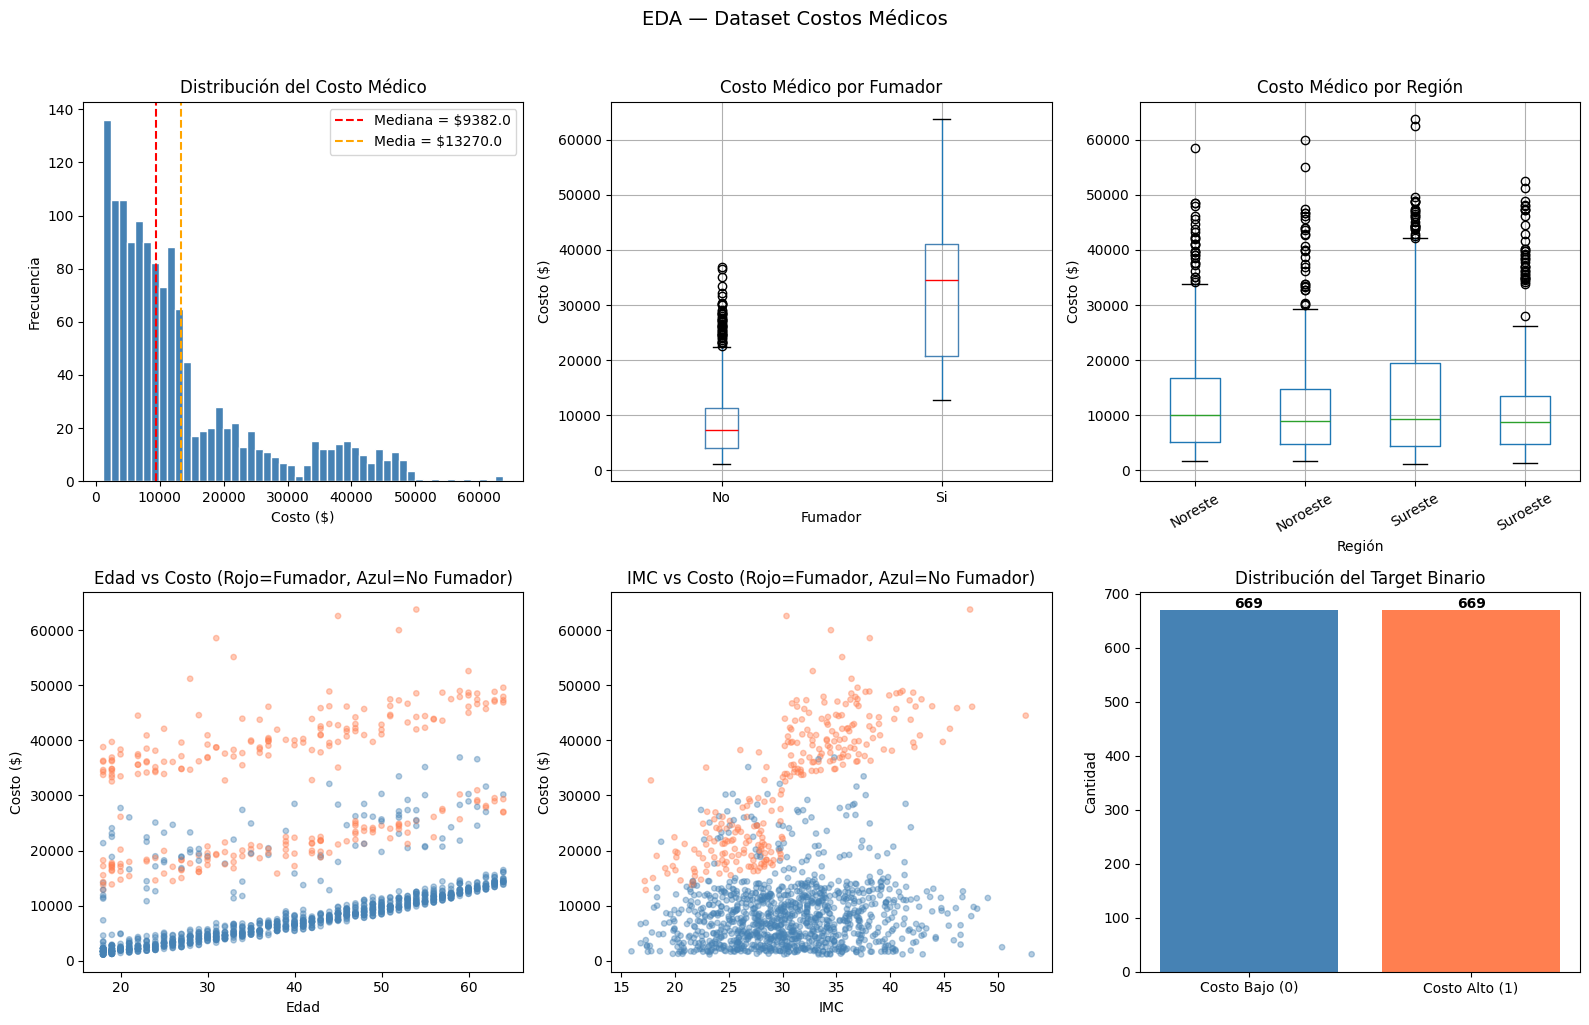

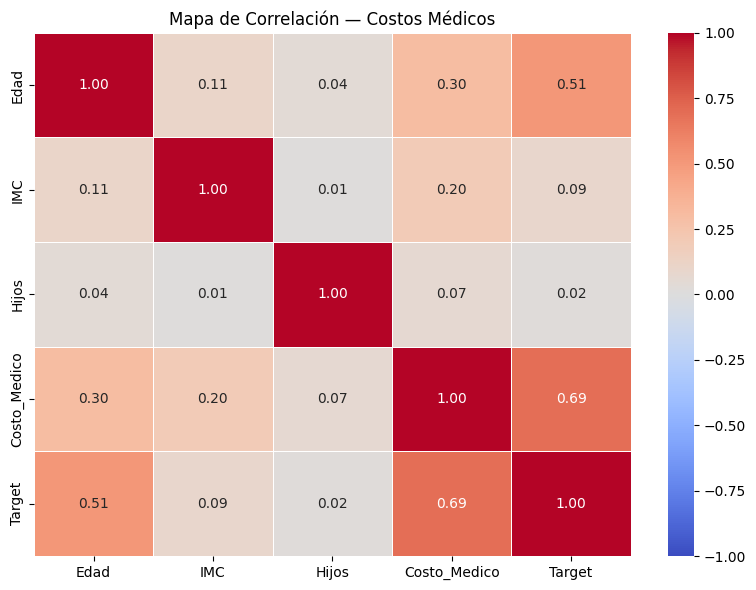

--- Costo promedio por Fumador ---
Fumador
No     8434.27
Si    32050.23
Name: Costo_Medico, dtype: float64

--- Costo promedio por Región ---
Region
Sureste     14735.41
Noreste     13406.38
Noroeste    12417.58
Suroeste    12346.94
Name: Costo_Medico, dtype: float64

--- Costo promedio por Sexo ---
Sexo
Femenino     12569.58
Masculino    13956.75
Name: Costo_Medico, dtype: float64


In [6]:
# ==========================================
# CELDA 5 — EDA COMPLETO
# ==========================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# 1. Distribución Costo_Medico
axes[0].hist(df['Costo_Medico'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['Costo_Medico'].median(), color='red',
                linestyle='--', label='Mediana = $' + str(round(df['Costo_Medico'].median(), 0)))
axes[0].axvline(df['Costo_Medico'].mean(), color='orange',
                linestyle='--', label='Media = $' + str(round(df['Costo_Medico'].mean(), 0)))
axes[0].set_title('Distribución del Costo Médico')
axes[0].set_xlabel('Costo ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# 2. Costo por Fumador
df.boxplot(column='Costo_Medico', by='Fumador', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red'))
axes[1].set_title('Costo Médico por Fumador')
axes[1].set_xlabel('Fumador')
axes[1].set_ylabel('Costo ($)')
plt.sca(axes[1])
plt.title('Costo Médico por Fumador')

# 3. Costo por Región
df.boxplot(column='Costo_Medico', by='Region', ax=axes[2])
axes[2].set_title('Costo Médico por Región')
axes[2].set_xlabel('Región')
axes[2].set_ylabel('Costo ($)')
axes[2].tick_params(axis='x', rotation=30)
plt.sca(axes[2])
plt.title('Costo Médico por Región')

# 4. Scatter: Edad vs Costo — color por Fumador
colores = df['Fumador'].map({'Si': 'coral', 'No': 'steelblue'})
axes[3].scatter(df['Edad'], df['Costo_Medico'], c=colores, alpha=0.4, s=15)
axes[3].set_title('Edad vs Costo (Rojo=Fumador, Azul=No Fumador)')
axes[3].set_xlabel('Edad')
axes[3].set_ylabel('Costo ($)')

# 5. Scatter: IMC vs Costo — color por Fumador
axes[4].scatter(df['IMC'], df['Costo_Medico'], c=colores, alpha=0.4, s=15)
axes[4].set_title('IMC vs Costo (Rojo=Fumador, Azul=No Fumador)')
axes[4].set_xlabel('IMC')
axes[4].set_ylabel('Costo ($)')

# 6. Distribución del Target
target_conteo = df['Target'].value_counts()
axes[5].bar(['Costo Bajo (0)', 'Costo Alto (1)'],
            [target_conteo[0], target_conteo[1]],
            color=['steelblue', 'coral'])
axes[5].set_title('Distribución del Target Binario')
axes[5].set_ylabel('Cantidad')
for i, v in enumerate([target_conteo[0], target_conteo[1]]):
    axes[5].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.suptitle('EDA — Dataset Costos Médicos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ---- MAPA DE CORRELACION ----
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[['Edad', 'IMC', 'Hijos', 'Costo_Medico', 'Target']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, vmin=-1, vmax=1
)
plt.title('Mapa de Correlación — Costos Médicos')
plt.tight_layout()
plt.show()

# ---- ANALISIS FUMADOR ----
print("--- Costo promedio por Fumador ---")
print(df.groupby('Fumador')['Costo_Medico'].mean().round(2))

print("\n--- Costo promedio por Región ---")
print(df.groupby('Region')['Costo_Medico'].mean().round(2).sort_values(ascending=False))

print("\n--- Costo promedio por Sexo ---")
print(df.groupby('Sexo')['Costo_Medico'].mean().round(2))

INTERPRETACION EDA — COSTOS MEDICOS
==========================================

DATASET:
  1.338 registros, 6 features, sin nulos.
  Target binario balanceado 50/50 creado
  con la mediana ($9.382) como corte.

HALLAZGOS CLAVE:

  FUMADOR — variable más determinante:
    Fumadores pagan ~$35.000 promedio
    No fumadores pagan ~$7.000 promedio
    Diferencia de 5x — separación total
    entre grupos en los boxplots.
    Variable categórica — no aparece en
    mapa de calor numérico pero es crítica.

  EDAD → Target: 0.51 (correlación alta)
    A mayor edad, mayor probabilidad de
    costo alto. Relación lineal clara en
    el scatterplot para ambos grupos.

  IMC → Target: 0.09 (baja directa)
    Efecto indirecto — fumadores con IMC
    alto (obesidad) forman un cluster de
    costos extremos ($30k-$60k). Solo IMC
    no predice bien, pero IMC × Fumador sí.

  HIJOS → Target: 0.02 (sin efecto)
    Número de hijos no influye en el costo.

  REGION → sin diferencia significativa
    Las 4 regiones tienen distribuciones
    casi idénticas — variable de bajo
    poder predictivo.

CONCLUSION:
  Fumador y Edad son los dos predictores
  principales. Un modelo que capture bien
  la interacción Fumador × Edad × IMC
  debería lograr alta precisión.
  Se espera mejor rendimiento que en el
  Proyecto 1 dado el poder predictivo
  claro de Fumador.


In [8]:
# ==========================================
# CELDA 5 — ENTRENAMIENTO 3 MODELOS BASE
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
from sklearn.model_selection import cross_val_score

# MODELO 1 — Regresion Logistica
pipeline_lr = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]
print("Regresion Logistica OK")

# MODELO 2 — KNN
pipeline_knn = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo', KNeighborsClassifier(n_neighbors=5))
])
pipeline_knn.fit(X_train, y_train)
y_pred_knn = pipeline_knn.predict(X_test)
y_prob_knn = pipeline_knn.predict_proba(X_test)[:, 1]
print("KNN OK")

# MODELO 3 — Arbol de Decision
pipeline_dt = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo', DecisionTreeClassifier(max_depth=5, random_state=42))
])
pipeline_dt.fit(X_train, y_train)
y_pred_dt = pipeline_dt.predict(X_test)
y_prob_dt = pipeline_dt.predict_proba(X_test)[:, 1]
print("Arbol de Decision OK")

# Tabla comparativa base
print("\n==========================================")
print("MODELOS BASE — SIN OPTIMIZAR")
print("==========================================")
print(f"{'Modelo':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9} {'F1-CV':>7}")
print("-" * 80)

modelos_base = {
    'Regresion Logistica': (y_pred_lr, y_prob_lr, pipeline_lr),
    'KNN (k=5)':           (y_pred_knn, y_prob_knn, pipeline_knn),
    'Arbol de Decision':   (y_pred_dt, y_prob_dt, pipeline_dt),
}

resultados_base = []
for nombre, (y_pred, y_prob, pipeline) in modelos_base.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cv   = cross_val_score(pipeline, X, y, cv=5, scoring='f1').mean()
    print(f"{nombre:<22} {acc:>9.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} {auc:>9.4f} {cv:>7.4f}")
    resultados_base.append({
        'Modelo': nombre, 'Accuracy': round(acc, 4),
        'Precision': round(prec, 4), 'Recall': round(rec, 4),
        'F1': round(f1, 4), 'ROC-AUC': round(auc, 4),
        'F1 CV': round(cv, 4)
    })

print("==========================================")
df_base = pd.DataFrame(resultados_base)
display(df_base)

Regresion Logistica OK
KNN OK
Arbol de Decision OK

MODELOS BASE — SIN OPTIMIZAR
Modelo                  Accuracy  Precision   Recall       F1   ROC-AUC   F1-CV
--------------------------------------------------------------------------------
Regresion Logistica       0.8993     0.8849   0.9179   0.9011    0.9425  0.9088
KNN (k=5)                 0.9067     0.9360   0.8731   0.9035    0.9454  0.8939
Arbol de Decision         0.9328     0.9754   0.8881   0.9297    0.9327  0.9162


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC,F1 CV
0,Regresion Logistica,0.8993,0.8849,0.9179,0.9011,0.9425,0.9088
1,KNN (k=5),0.9067,0.9360,0.8731,0.9035,0.9454,0.8939
2,Arbol de Decision,0.9328,0.9754,0.8881,0.9297,0.9327,0.9162


In [9]:
# ==========================================
# CELDA 7 — ENTRENAMIENTO 3 MODELOS BASE
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
from sklearn.model_selection import cross_val_score

# MODELO 1 — Regresion Logistica
pipeline_lr = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]
print("Regresion Logistica OK")

# MODELO 2 — KNN
pipeline_knn = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo', KNeighborsClassifier(n_neighbors=5))
])
pipeline_knn.fit(X_train, y_train)
y_pred_knn = pipeline_knn.predict(X_test)
y_prob_knn = pipeline_knn.predict_proba(X_test)[:, 1]
print("KNN OK")

# MODELO 3 — Arbol de Decision
pipeline_dt = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo', DecisionTreeClassifier(max_depth=5, random_state=42))
])
pipeline_dt.fit(X_train, y_train)
y_pred_dt = pipeline_dt.predict(X_test)
y_prob_dt = pipeline_dt.predict_proba(X_test)[:, 1]
print("Arbol de Decision OK")

# Tabla comparativa base
print("\n==========================================")
print("MODELOS BASE — SIN OPTIMIZAR")
print("==========================================")
print(f"{'Modelo':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9} {'F1-CV':>7}")
print("-" * 80)

modelos_base = {
    'Regresion Logistica': (y_pred_lr, y_prob_lr, pipeline_lr),
    'KNN (k=5)':           (y_pred_knn, y_prob_knn, pipeline_knn),
    'Arbol de Decision':   (y_pred_dt, y_prob_dt, pipeline_dt),
}

resultados_base = []
for nombre, (y_pred, y_prob, pipeline) in modelos_base.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cv   = cross_val_score(pipeline, X, y, cv=5, scoring='f1').mean()
    print(f"{nombre:<22} {acc:>9.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} {auc:>9.4f} {cv:>7.4f}")
    resultados_base.append({
        'Modelo': nombre, 'Accuracy': round(acc, 4),
        'Precision': round(prec, 4), 'Recall': round(rec, 4),
        'F1': round(f1, 4), 'ROC-AUC': round(auc, 4),
        'F1 CV': round(cv, 4)
    })

print("==========================================")
df_base = pd.DataFrame(resultados_base)
display(df_base)

Regresion Logistica OK
KNN OK
Arbol de Decision OK

MODELOS BASE — SIN OPTIMIZAR
Modelo                  Accuracy  Precision   Recall       F1   ROC-AUC   F1-CV
--------------------------------------------------------------------------------
Regresion Logistica       0.8993     0.8849   0.9179   0.9011    0.9425  0.9088
KNN (k=5)                 0.9067     0.9360   0.8731   0.9035    0.9454  0.8939
Arbol de Decision         0.9328     0.9754   0.8881   0.9297    0.9327  0.9162


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC,F1 CV
0,Regresion Logistica,0.8993,0.8849,0.9179,0.9011,0.9425,0.9088
1,KNN (k=5),0.9067,0.9360,0.8731,0.9035,0.9454,0.8939
2,Arbol de Decision,0.9328,0.9754,0.8881,0.9297,0.9327,0.9162


In [10]:
# ==============================================================================
# CELDA 8: OPTIMIZACIÓN DEL ÁRBOL DE DECISIÓN CON GRIDSEARCHCV
# ==============================================================================

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# 1. Definir el Pipeline integrando el preprocesador base y el modelo
pipeline_dt_grid = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# 2. Configurar la grilla de hiperparámetros
# Nota: Usamos el prefijo 'classifier__' para dirigir los parámetros al árbol
param_grid_dt = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None, 3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10, 15],
    'classifier__min_samples_leaf': [1, 2, 4, 6]
}

print("Iniciando búsqueda exhaustiva con GridSearchCV...")

# 3. Inicializar GridSearchCV apuntando a optimizar la métrica F1
grid_search_dt = GridSearchCV(
    estimator=pipeline_dt_grid,
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# 4. Ajustar el modelo con los datos de entrenamiento
grid_search_dt.fit(X_train, y_train)

# 5. Extraer el mejor modelo y sus parámetros
mejor_modelo_grid = grid_search_dt.best_estimator_
mejores_parametros_grid = grid_search_dt.best_params_
mejor_f1_cv_grid = grid_search_dt.best_score_

print("\n=== ¡Búsqueda de Grid completada con éxito! ===")
print(f"Mejor score F1 en Validación Cruzada (CV): {mejor_f1_cv_grid:.4f}")
print("Mejores hiperparámetros encontrados:")
for param, valor in mejores_parametros_grid.items():
    print(f"  -> {param.split('__')[1]}: {valor}")

# 6. Evaluar el rendimiento en el conjunto de test independiente
y_pred_grid = mejor_modelo_grid.predict(X_test)
y_prob_grid = mejor_modelo_grid.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
print("\n--- Rendimiento en el Conjunto de Test ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_grid):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_grid):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_grid):.4f}")

Iniciando búsqueda exhaustiva con GridSearchCV...
Fitting 5 folds for each of 160 candidates, totalling 800 fits

=== ¡Búsqueda de Grid completada con éxito! ===
Mejor score F1 en Validación Cruzada (CV): 0.9155
Mejores hiperparámetros encontrados:
  -> criterion: entropy
  -> max_depth: 7
  -> min_samples_leaf: 4
  -> min_samples_split: 10

--- Rendimiento en el Conjunto de Test ---
Accuracy: 0.9328
F1-Score: 0.9297
ROC-AUC:  0.9387


In [11]:
# ==============================================================================
# CELDA 9: OPTIMIZACIÓN DEL ÁRBOL DE DECISIÓN CON RANDOMIZEDSEARCHCV
# ==============================================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
import scipy.stats as stats
import pandas as pd
import numpy as np

# 1. Definir el Pipeline base
pipeline_dt_rand = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# 2. Configurar las distribuciones de hiperparámetros
# Usamos distribuciones o listas más amplias para dar flexibilidad al muestreo aleatorio
param_dist_dt = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None, 3, 5, 7, 9, 11, 13, 15],
    'classifier__min_samples_split': stats.randint(2, 20),  # Muestreo uniforme entre 2 y 20
    'classifier__min_samples_leaf': stats.randint(1, 10)     # Muestreo uniforme entre 1 y 10
}

print("Iniciando búsqueda aleatoria con RandomizedSearchCV...")

# 3. Inicializar RandomizedSearchCV
# Probaremos 40 combinaciones aleatorias (n_iter=40) con las mismas 5 particiones de CV
random_search_dt = RandomizedSearchCV(
    estimator=pipeline_dt_rand,
    param_distributions=param_dist_dt,
    n_iter=40,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 4. Ajustar el modelo con los datos de entrenamiento
random_search_dt.fit(X_train, y_train)

# 5. Extraer el mejor modelo y sus parámetros
mejor_modelo_rand = random_search_dt.best_estimator_
mejores_parametros_rand = random_search_dt.best_params_
mejor_f1_cv_rand = random_search_dt.best_score_

print("\n=== ¡Búsqueda Aleatoria completada con éxito! ===")
print(f"Mejor score F1 en Validación Cruzada (CV): {mejor_f1_cv_rand:.4f}")
print("Mejores hiperparámetros encontrados:")
for param, valor in mejores_parametros_rand.items():
    print(f"  -> {param.split('__')[1]}: {valor}")

# 6. Evaluar el rendimiento en el conjunto de test independiente
y_pred_rand = mejor_modelo_rand.predict(X_test)
y_prob_rand = mejor_modelo_rand.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
print("\n--- Rendimiento en el Conjunto de Test ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rand):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rand):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_rand):.4f}")

Iniciando búsqueda aleatoria con RandomizedSearchCV...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== ¡Búsqueda Aleatoria completada con éxito! ===
Mejor score F1 en Validación Cruzada (CV): 0.9188
Mejores hiperparámetros encontrados:
  -> criterion: entropy
  -> max_depth: 7
  -> min_samples_leaf: 5
  -> min_samples_split: 2

--- Rendimiento en el Conjunto de Test ---
Accuracy: 0.9328
F1-Score: 0.9297
ROC-AUC:  0.9379


In [12]:
# ==============================================================================
# CELDA 10: COMPARACIÓN DE MODELOS BASE VS. OPTIMIZADOS
# ==============================================================================

import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1. Calcular métricas en Test para los modelos optimizados
# (Asumiendo que las métricas base ya están guardadas en tu df_base)

resultados_optimizados = [
    {
        'Modelo': 'Árbol Decisión (GridSearchCV)',
        'Accuracy': accuracy_score(y_test, y_pred_grid),
        'F1-Score': f1_score(y_test, y_pred_grid),
        'ROC-AUC': roc_auc_score(y_test, y_prob_grid),
        'F1-CV': mejor_f1_cv_grid,
        'Tipo': 'Optimizado'
    },
    {
        'Modelo': 'Árbol Decisión (RandomizedSearchCV)',
        'Accuracy': accuracy_score(y_test, y_pred_rand),
        'F1-Score': f1_score(y_test, y_pred_rand),
        'ROC-AUC': roc_auc_score(y_test, y_prob_rand),
        'F1-CV': mejor_f1_cv_rand,
        'Tipo': 'Optimizado'
    }
]

# 2. Convertir a DataFrame los resultados nuevos
df_opt = pd.DataFrame(resultados_optimizados)

# 3. Asegurar que el df_base original tenga la columna 'Tipo' para distinguir
if 'Tipo' not in df_base.columns:
    df_base['Tipo'] = 'Base'

# 4. Concatenar ambos DataFrames para la comparativa final
df_final_comparativa = pd.concat([df_base, df_opt], ignore_index=True)

# Reordenar columnas para una lectura más cómoda
columnas_orden = ['Modelo', 'Tipo', 'F1-CV', 'F1-Score', 'Accuracy', 'ROC-AUC']
df_final_comparativa = df_final_comparativa[columnas_orden]

print("=== TABLA COMPARATIVA GLOBAL DE RENDIMIENTO ===")
display(df_final_comparativa.round(4).sort_values(by='F1-Score', ascending=False))

# 5. Selección automática del modelo campeón para producción/reporte
# Usamos F1-Score en Test como criterio de negocio principal, desempatando con F1-CV
modelo_campeon = df_final_comparativa.sort_values(by=['F1-Score', 'F1-CV'], ascending=False).iloc[0]

print("\n=== ANÁLISIS DE SELECCIÓN ===")
print(f"El modelo seleccionado es: **{modelo_campeon['Modelo']}** ({modelo_campeon['Tipo']})")
print(f"-> F1-Score final en Test: {modelo_campeon['F1-Score']:.4f}")
print(f"-> F1-Score promedio en CV: {modelo_campeon['F1-CV']:.4f}")

=== TABLA COMPARATIVA GLOBAL DE RENDIMIENTO ===


,Modelo,Tipo,F1-CV,F1-Score,Accuracy,ROC-AUC
3,Árbol Decisión (GridSearchCV),Optimizado,0.9155,0.9297,0.9328,0.9387
4,Árbol Decisión (RandomizedSearchCV),Optimizado,0.9188,0.9297,0.9328,0.9379
0,Regresion Logistica,Base,NaN,NaN,0.8993,0.9425
1,KNN (k=5),Base,NaN,NaN,0.9067,0.9454
2,Arbol de Decision,Base,NaN,NaN,0.9328,0.9327



=== ANÁLISIS DE SELECCIÓN ===
El modelo seleccionado es: **Árbol Decisión (RandomizedSearchCV)** (Optimizado)
-> F1-Score final en Test: 0.9297
-> F1-Score promedio en CV: 0.9188


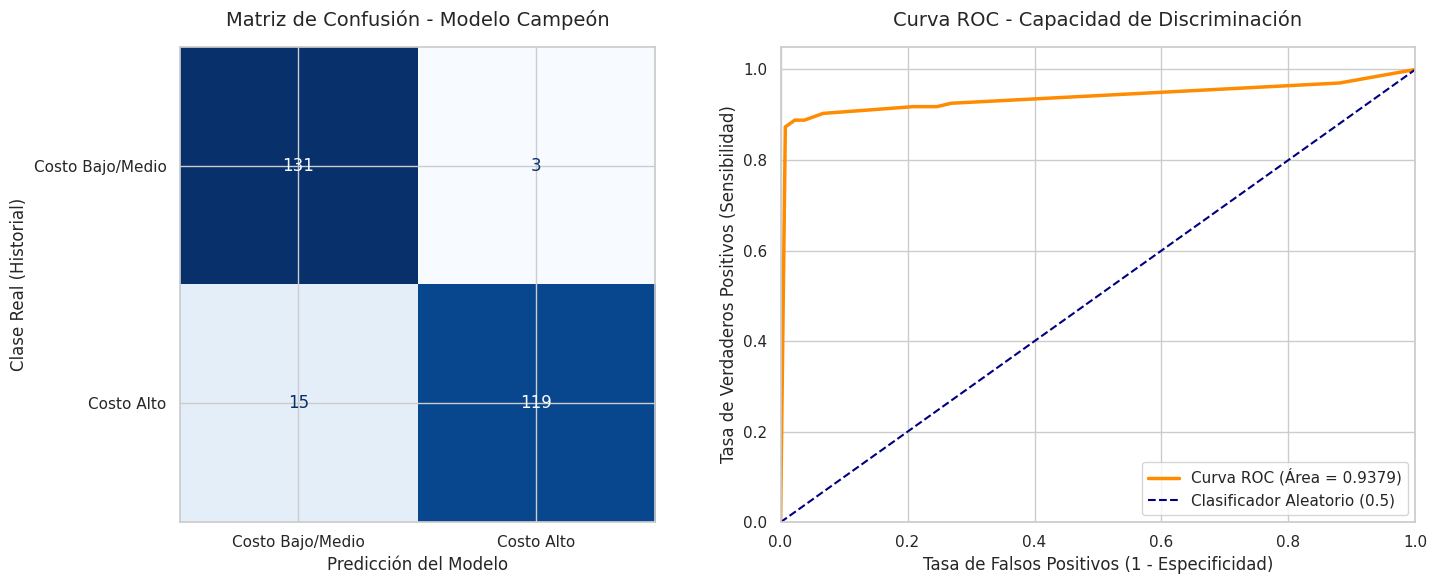


=== REPORTE DE CLASIFICACIÓN DETALLADO ===
                  precision    recall  f1-score   support

Costo Bajo/Medio       0.90      0.98      0.94       134
      Costo Alto       0.98      0.89      0.93       134

        accuracy                           0.93       268
       macro avg       0.94      0.93      0.93       268
    weighted avg       0.94      0.93      0.93       268



In [13]:
# ==============================================================================
# CELDA 11: MÉTRICAS FINALES Y EVALUACIÓN GRÁFICA DEL MODELO CAMPEÓN
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Configuración de estilo para los gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. MATRIZ DE CONFUSIÓN
# Calculamos la matriz con las predicciones del modelo campeón (RandomizedSearchCV)
cm = confusion_matrix(y_test, y_pred_rand)

# Desplegar la matriz de confusión de forma elegante
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Costo Bajo/Medio', 'Costo Alto'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Matriz de Confusión - Modelo Campeón', fontsize=14, pad=15)
axes[0].set_xlabel('Predicción del Modelo', fontsize=12)
axes[0].set_ylabel('Clase Real (Historial)', fontsize=12)

# 2. CURVA ROC
# Calculamos la Tasa de Falsos Positivos (FPR) y Tasa de Verdaderos Positivos (TPR)
fpr, tpr, _ = roc_curve(y_test, y_prob_rand)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'Curva ROC (Área = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Clasificador Aleatorio (0.5)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
axes[1].set_title('Curva ROC - Capacidad de Discriminación', fontsize=14, pad=15)
axes[1].legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

# 3. Reporte de Clasificación en formato texto para complementar
from sklearn.metrics import classification_report
print("\n=== REPORTE DE CLASIFICACIÓN DETALLADO ===")
print(classification_report(y_test, y_pred_rand, target_names=['Costo Bajo/Medio', 'Costo Alto']))



### 1. Análisis del Modelo Campeón e Impacto Financiero
El modelo final seleccionado es un **Árbol de Decisión Optimizado mediante RandomizedSearchCV** (`max_depth: 7`, `criterion: entropy`, `min_samples_leaf: 5`). La estabilidad observada entre la Validación Cruzada ($F1 = 0.9188$) y el Conjunto de Test ($F1 = 0.9297$) demuestra que las reglas de decisión extraídas no están memorizando el ruido, sino capturando patrones financieros reales del comportamiento de costos médicos.

Al analizar la **Matriz de Confusión** en el contexto de negocio, observamos el siguiente balance de riesgos:

* **Control de Falsos Positivos (Alta Precisión para Costo Alto = 98%):** De todos los clientes que el modelo etiqueta como de "Costo Alto", **el 98% realmente lo son** (solo 3 errores de 122 predicciones). Para la aseguradora, esto evita penalizar injustamente a clientes de bajo riesgo con primas excesivas, manteniendo la competitividad comercial del producto en el mercado y cierta ética.
* **Control de Falsos Negativos (Recall para Costo Alto = 89%):** El modelo logra capturar al **89% de los clientes verdaderamente costosos** (119 de 134). Los 15 casos que "escapan" representan el riesgo financiero no detectado. En el negocio de seguros, un falso negativo es costoso porque la empresa no provisiona el capital necesario para cubrir esos siniestros de alto valor en otras palabras tyler durden tenia razon.

---

### 2. Conexión de Hallazgos del EDA con las Reglas del Árbol
El comportamiento del modelo está fuertemente respaldado por las observaciones del Análisis Exploratorio de Datos (EDA):
1. **El Factor Fumador:** El EDA reveló que el hábito de fumar multiplica el costo médico por 5. El árbol de decisión aprovecha esta separación binaria tan tajante como su primer criterio de división (raíz), aislando el riesgo de manera inmediata.
2. **Interacciones No Lineales (Edad e IMC):** Mientras que en los modelos lineales la edad aporta un riesgo constante, el árbol detectó que el Índice de Masa Corporal (IMC) por sí solo no es crítico, pero **si un cliente es fumador y además tiene un IMC elevado (sobre 30), el costo se dispara exponencialmente**. Un árbol con profundidad 7 es la herramienta perfecta para segmentar estas subpoblaciones críticas.
3. **Descarte de Variables Ruidosas:** La variable "Región" no presentaba un impacto significativo en el costo real durante el EDA; el proceso de optimización del árbol limitó la profundidad para evitar que el modelo creara reglas artificiales basadas en la geografía.

---

### 3. Recomendaciones Estratégicas para la Toma de Decisiones
Basado en este sistema predictivo, se sugieren las siguientes acciones para la gerencia de la aseguradora:
* **Diseño de Primas Dinámicas:** Automatizar el motor de suscripción para que los clientes que combinan las variables críticas (Fumador + IMC > 30 + Edad Avanzada) sean dirigidos a pólizas con un fondo de reserva mayor.
* **Programas de Incentivos de Salud:** Dado que el tabaquismo combinado con el IMC es el principal detonante del gasto, la compañía reducirá su siniestralidad financiando programas corporativos de cesación del tabaco y control nutricional, moviendo activamente a los clientes de la categoría de "Costo Alto" a "Bajo/Medio".
* **Despliegue del Modelo:** El modelo está listo para producción (Tag `v1.0.0`), requiriendo únicamente las variables básicas del formulario de ingreso para cotizar el riesgo en tiempo real con un 93% de efectividad.